<a href="https://colab.research.google.com/github/MaLith344/Statistical-Learning-e21344/blob/main/GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [1]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [2]:
import os
import pandas as pd

print(f"Listing contents of: {path}")
!ls {path}
df2 = pd.read_csv(path + "/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


## Step 1: Data Exploration

Before fitting any model, we must understand the structure of the dataset. The ENB2012 dataset (768 samples) contains:

| Feature | Description |
|---------|-------------|
| X1 | Relative Compactness |
| X2 | Surface Area (m²) |
| X3 | Wall Area (m²) |
| X4 | Roof Area (m²) |
| X5 | Overall Height (m) |
| X6 | Orientation (categorical: 2–5) |
| X7 | Glazing Area (fraction: 0, 0.1, 0.25, 0.4) |
| X8 | Glazing Area Distribution (categorical: 0–5) |
| **Y1** | **Heating Load (kWh/m²)** |
| **Y2** | **Cooling Load (kWh/m²)** |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Rename columns for clarity
df2.columns = ['X1_Compactness', 'X2_SurfaceArea', 'X3_WallArea', 'X4_RoofArea',
               'X5_Height', 'X6_Orientation', 'X7_GlazingArea', 'X8_GlazingDist',
               'Y1_HeatingLoad', 'Y2_CoolingLoad']

print("Dataset shape:", df2.shape)
print("\nFirst 5 rows:")
df2.head()

Dataset shape: (768, 10)

First 5 rows:


,X1_Compactness,X2_SurfaceArea,X3_WallArea,X4_RoofArea,X5_Height,X6_Orientation,X7_GlazingArea,X8_GlazingDist,Y1_HeatingLoad,Y2_CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
print("Summary Statistics:")
print(df2.describe().T.round(3))
print("\nMissing values:", df2.isnull().sum().sum())

Summary Statistics:
                count     mean     std     min      25%     50%      75%  \
X1_Compactness  768.0    0.764   0.106    0.62    0.682    0.75    0.830   
X2_SurfaceArea  768.0  671.708  88.086  514.50  606.375  673.75  741.125   
X3_WallArea     768.0  318.500  43.626  245.00  294.000  318.50  343.000   
X4_RoofArea     768.0  176.604  45.166  110.25  140.875  183.75  220.500   
X5_Height       768.0    5.250   1.751    3.50    3.500    5.25    7.000   
X6_Orientation  768.0    3.500   1.119    2.00    2.750    3.50    4.250   
X7_GlazingArea  768.0    0.234   0.133    0.00    0.100    0.25    0.400   
X8_GlazingDist  768.0    2.812   1.551    0.00    1.750    3.00    4.000   
Y1_HeatingLoad  768.0   22.307  10.090    6.01   12.992   18.95   31.668   
Y2_CoolingLoad  768.0   24.588   9.513   10.90   15.620   22.08   33.132   

                   max  
X1_Compactness    0.98  
X2_SurfaceArea  808.50  
X3_WallArea     416.50  
X4_RoofArea     220.50  
X5_Height         

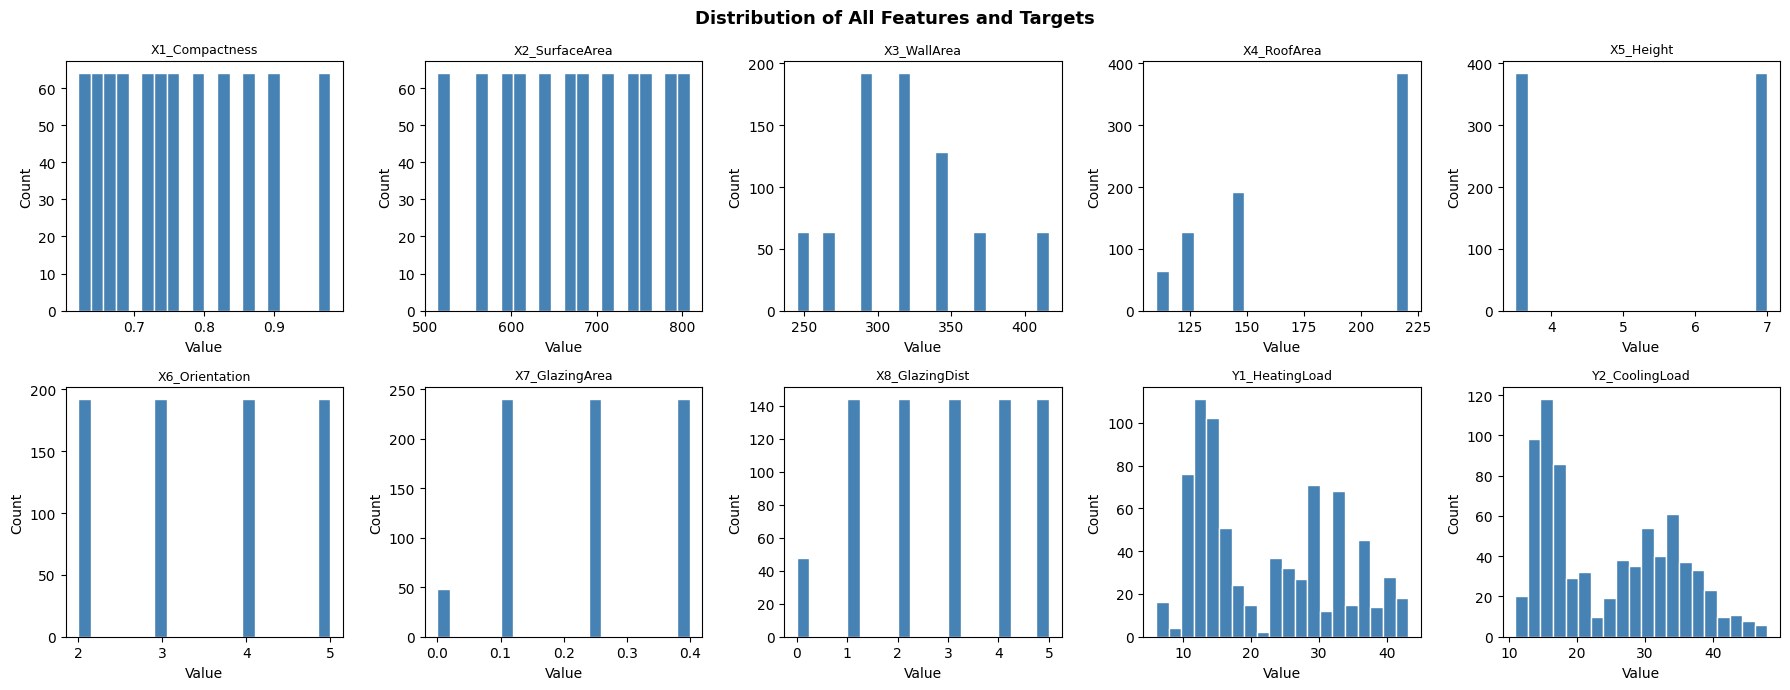

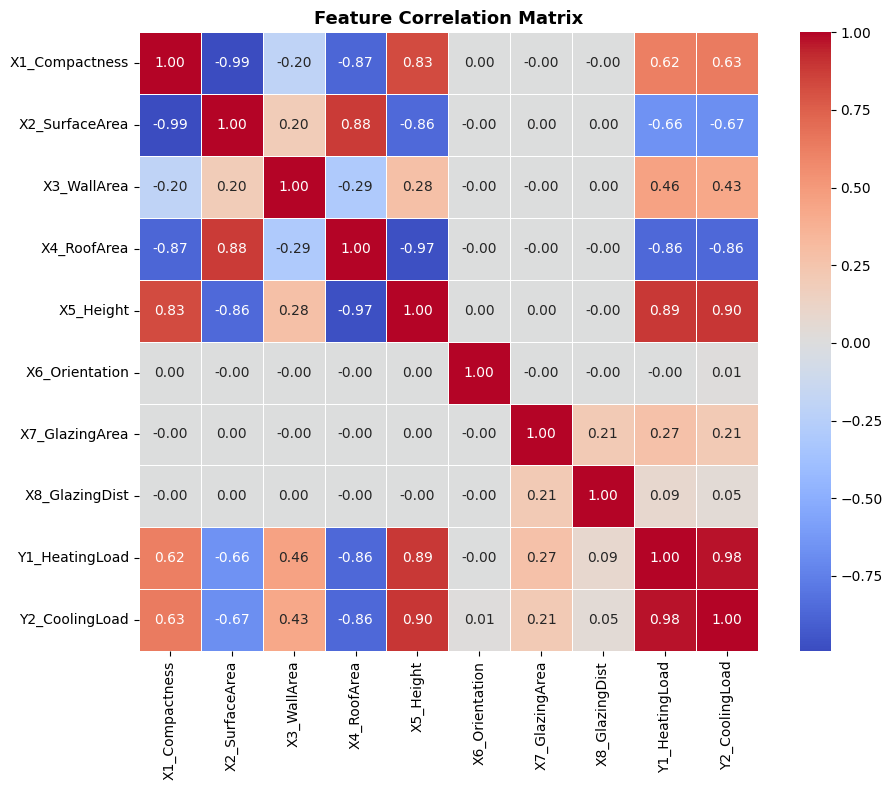

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(df2.columns):
    axes[i].hist(df2[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of All Features and Targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df2.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

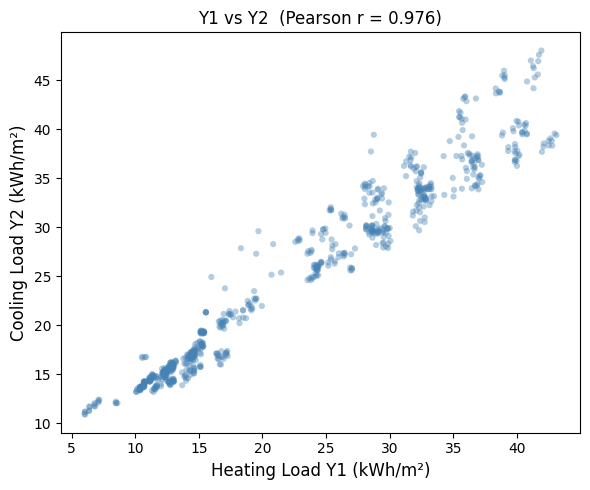

Pearson correlation between Y1 and Y2: 0.9759


In [6]:
# Scatter plot of Y1 vs Y2 to assess their relationship
plt.figure(figsize=(6, 5))
plt.scatter(df2['Y1_HeatingLoad'], df2['Y2_CoolingLoad'],
            alpha=0.4, color='steelblue', edgecolors='none', s=20)
plt.xlabel('Heating Load Y1 (kWh/m²)', fontsize=12)
plt.ylabel('Cooling Load Y2 (kWh/m²)', fontsize=12)
corr_y1y2 = df2['Y1_HeatingLoad'].corr(df2['Y2_CoolingLoad'])
plt.title(f'Y1 vs Y2  (Pearson r = {corr_y1y2:.3f})', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Pearson correlation between Y1 and Y2: {corr_y1y2:.4f}")

## Step 2: Gaussian Process Regression — Theory

A **Gaussian Process (GP)** is a collection of random variables, any finite subset of which follows a joint Gaussian distribution. A GP is fully specified by:
- A **mean function** $m(\mathbf{x})$, commonly set to zero.
- A **covariance (kernel) function** $k(\mathbf{x}, \mathbf{x}')$, encoding smoothness priors.

We write: $f(\mathbf{x}) \sim \mathcal{GP}\bigl(m(\mathbf{x}),\; k(\mathbf{x}, \mathbf{x}')\bigr)$

Given noisy observations $y_i = f(\mathbf{x}_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$, the **posterior predictive distribution** at a new input $\mathbf{x}_*$ is Gaussian:

$$\bar{f}_* = k(\mathbf{x}_*, X)\,[K(X,X) + \sigma_n^2 I]^{-1}\,\mathbf{y}$$
$$\text{Var}(f_*) = k(\mathbf{x}_*,\mathbf{x}_*) - k(\mathbf{x}_*, X)\,[K(X,X)+\sigma_n^2 I]^{-1}\,k(X,\mathbf{x}_*)$$

Hyperparameters ($\ell$, $\sigma_f^2$, $\sigma_n^2$) are learnt by maximising the **log marginal likelihood**:
$$\log p(\mathbf{y}\mid X,\theta) = -\tfrac{1}{2}\mathbf{y}^\top K_y^{-1}\mathbf{y} - \tfrac{1}{2}\log|K_y| - \tfrac{n}{2}\log 2\pi$$

### Kernels used
| Kernel | Formula | Property |
|--------|---------|----------|
| **RBF** | $\sigma_f^2 \exp\!\left(-\frac{\|x-x'\|^2}{2\ell^2}\right)$ | Infinitely differentiable |
| **Matérn 5/2** | $\sigma_f^2\left(1+\frac{\sqrt{5}r}{\ell}+\frac{5r^2}{3\ell^2}\right)e^{-\frac{\sqrt{5}r}{\ell}}$ | Twice differentiable |

We use **Automatic Relevance Determination (ARD)**: a separate length-scale $\ell_d$ per input dimension $d$, allowing the GP to learn which features matter most.

## Step 3: GPR for Heating Load (Y1)

In [7]:
# ── Prepare and scale data ──
feature_cols = ['X1_Compactness', 'X2_SurfaceArea', 'X3_WallArea', 'X4_RoofArea',
                'X5_Height', 'X6_Orientation', 'X7_GlazingArea', 'X8_GlazingDist']
X = df2[feature_cols].values
y1 = df2['Y1_HeatingLoad'].values
y2 = df2['Y2_CoolingLoad'].values

scaler_X  = StandardScaler()
X_scaled  = scaler_X.fit_transform(X)

scaler_y1 = StandardScaler()
y1_scaled = scaler_y1.fit_transform(y1.reshape(-1, 1)).ravel()

scaler_y2 = StandardScaler()
y2_scaled = scaler_y2.fit_transform(y2.reshape(-1, 1)).ravel()

X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X_scaled, y1_scaled, y2_scaled, test_size=0.20, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 614
Test samples     : 154


In [8]:
# ── Define ARD kernels with white noise ──
n_feat = X_train.shape[1]

kernel_rbf = (C(1.0, (1e-3, 1e3))
              * RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-2, 1e2))
              + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))

kernel_matern = (C(1.0, (1e-3, 1e3))
                 * Matern(length_scale=np.ones(n_feat), nu=2.5,
                          length_scale_bounds=(1e-2, 1e2))
                 + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))

# Fit GPR Y1 — RBF
print("Fitting GPR (RBF) for Y1 ...")
gpr_y1_rbf = GaussianProcessRegressor(kernel=kernel_rbf, n_restarts_optimizer=5,
                                       normalize_y=False, random_state=42)
gpr_y1_rbf.fit(X_train, y1_train)

# Fit GPR Y1 — Matern
print("Fitting GPR (Matérn 5/2) for Y1 ...")
gpr_y1_mat = GaussianProcessRegressor(
    kernel=kernel_matern.__class__(**kernel_matern.get_params()),
    n_restarts_optimizer=5, normalize_y=False, random_state=42)
# Re-instantiate to avoid sharing kernel state
kernel_matern2 = (C(1.0, (1e-3, 1e3))
                  * Matern(length_scale=np.ones(n_feat), nu=2.5,
                           length_scale_bounds=(1e-2, 1e2))
                  + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
gpr_y1_mat = GaussianProcessRegressor(kernel=kernel_matern2, n_restarts_optimizer=5,
                                       normalize_y=False, random_state=42)
gpr_y1_mat.fit(X_train, y1_train)

print("\nOptimised RBF kernel :",   gpr_y1_rbf.kernel_)
print("Optimised Matérn kernel:", gpr_y1_mat.kernel_)

Fitting GPR (RBF) for Y1 ...
Fitting GPR (Matérn 5/2) for Y1 ...


TypeError: KernelOperator.__init__() got an unexpected keyword argument 'k1__k1'

In [ ]:
def evaluate_gpr(model, X_test, y_test_scaled, scaler_y, label):
    """Predict, invert scaling, compute metrics."""
    y_pred_s, y_std_s = model.predict(X_test, return_std=True)
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
    y_std  = y_std_s * scaler_y.scale_[0]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:15s}  RMSE = {rmse:.4f}  |  R² = {r2:.4f}")
    return y_pred, y_true, y_std

print("=== Heating Load (Y1) – Test Set ===")
y1_pred_rbf, y1_true, y1_std_rbf = evaluate_gpr(gpr_y1_rbf, X_test, y1_test, scaler_y1, 'RBF')
y1_pred_mat, _,       y1_std_mat = evaluate_gpr(gpr_y1_mat, X_test, y1_test, scaler_y1, 'Matérn 5/2')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, y_std, title in zip(
        axes,
        [y1_pred_rbf, y1_pred_mat],
        [y1_std_rbf,  y1_std_mat],
        ['GPR – RBF Kernel (Y1 Heating Load)',
         'GPR – Matérn 5/2 Kernel (Y1 Heating Load)']):
    idx = np.argsort(y1_true)
    ax.errorbar(y1_true[idx], y_pred[idx], yerr=2*y_std[idx],
                fmt='o', markersize=3, alpha=0.5, capsize=2,
                color='steelblue', ecolor='lightblue', label='Prediction ± 2σ')
    lim = [y1_true.min()-1, y1_true.max()+1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('True Heating Load (kWh/m²)'); ax.set_ylabel('Predicted (kWh/m²)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout(); plt.show()

## Step 4: GPR for Cooling Load (Y2)

In [ ]:
kernel_rbf3 = (C(1.0, (1e-3, 1e3))
               * RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-2, 1e2))
               + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
kernel_mat3 = (C(1.0, (1e-3, 1e3))
               * Matern(length_scale=np.ones(n_feat), nu=2.5,
                        length_scale_bounds=(1e-2, 1e2))
               + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))

print("Fitting GPR (RBF) for Y2 ...")
gpr_y2_rbf = GaussianProcessRegressor(kernel=kernel_rbf3, n_restarts_optimizer=5,
                                       normalize_y=False, random_state=42)
gpr_y2_rbf.fit(X_train, y2_train)

print("Fitting GPR (Matérn 5/2) for Y2 ...")
gpr_y2_mat = GaussianProcessRegressor(kernel=kernel_mat3, n_restarts_optimizer=5,
                                       normalize_y=False, random_state=42)
gpr_y2_mat.fit(X_train, y2_train)

print("\n=== Cooling Load (Y2) – Test Set ===")
y2_pred_rbf, y2_true, y2_std_rbf = evaluate_gpr(gpr_y2_rbf, X_test, y2_test, scaler_y2, 'RBF')
y2_pred_mat, _,       y2_std_mat = evaluate_gpr(gpr_y2_mat, X_test, y2_test, scaler_y2, 'Matérn 5/2')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, y_std, title in zip(
        axes,
        [y2_pred_rbf, y2_pred_mat],
        [y2_std_rbf,  y2_std_mat],
        ['GPR – RBF Kernel (Y2 Cooling Load)',
         'GPR – Matérn 5/2 Kernel (Y2 Cooling Load)']):
    idx = np.argsort(y2_true)
    ax.errorbar(y2_true[idx], y_pred[idx], yerr=2*y_std[idx],
                fmt='o', markersize=3, alpha=0.5, capsize=2,
                color='darkorange', ecolor='moccasin', label='Prediction ± 2σ')
    lim = [y2_true.min()-1, y2_true.max()+1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('True Cooling Load (kWh/m²)'); ax.set_ylabel('Predicted (kWh/m²)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout(); plt.show()

## Step 5: ARD Length-Scale Analysis

The learned per-feature length-scales reveal feature importance:
- **Small length-scale** → the GP is sensitive to small changes in that feature → high relevance.
- **Large length-scale** → the feature has little influence on the output.

In [ ]:
def get_ard_ls(gpr_model):
    """Extract ARD length-scales from a fitted GPR (Product + WhiteKernel structure)."""
    # kernel_ is k1 (Product) + k2 (WhiteKernel)
    # k1 is C * RBF/Matérn
    return gpr_model.kernel_.k1.k2.length_scale

ls_results = {
    'Y1 – RBF':    get_ard_ls(gpr_y1_rbf),
    'Y1 – Matérn': get_ard_ls(gpr_y1_mat),
    'Y2 – RBF':    get_ard_ls(gpr_y2_rbf),
    'Y2 – Matérn': get_ard_ls(gpr_y2_mat),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['steelblue', 'royalblue', 'darkorange', 'orangered']
for ax, (title, ls), color in zip(axes.flatten(), ls_results.items(), colors):
    ax.bar(feature_cols, ls, color=color, alpha=0.75)
    ax.set_title(f'ARD Length-Scales – {title}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Length-scale (larger = less important)')
    ax.set_xticks(range(len(feature_cols)))
    ax.set_xticklabels(feature_cols, rotation=40, ha='right', fontsize=8)
plt.suptitle('ARD Length-Scales per Feature  (smaller = more influential)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Step 6: Uncertainty Calibration and Residual Analysis

In [ ]:
def calibration_check(y_true, y_pred, y_std, label):
    print(f"  {label}")
    for k, expected in [(1, 68.27), (2, 95.45), (3, 99.73)]:
        frac = np.mean(np.abs(y_true - y_pred) <= k * y_std) * 100
        print(f"    ±{k}σ: {frac:.1f}%  (ideal ~{expected:.1f}%)")

print("=== Predictive Interval Calibration ===")
calibration_check(y1_true, y1_pred_rbf, y1_std_rbf, 'Y1 – RBF')
calibration_check(y1_true, y1_pred_mat, y1_std_mat, 'Y1 – Matérn')
calibration_check(y2_true, y2_pred_rbf, y2_std_rbf, 'Y2 – RBF')
calibration_check(y2_true, y2_pred_mat, y2_std_mat, 'Y2 – Matérn')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, y_true_, y_std, label, color in [
    (axes[0], y1_pred_mat, y1_true, y1_std_mat, 'Y1 Heating Load (Matérn)', 'steelblue'),
    (axes[1], y2_pred_mat, y2_true, y2_std_mat, 'Y2 Cooling Load (Matérn)', 'darkorange'),
]:
    residuals = y_true_ - y_pred
    sc = ax.scatter(y_pred, residuals, c=y_std, cmap='viridis', s=15, alpha=0.7)
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel('Predicted (kWh/m²)', fontsize=11)
    ax.set_ylabel('Residual (kWh/m²)', fontsize=11)
    ax.set_title(f'Residuals vs Predicted – {label}\n(colour = predictive std σ)',
                 fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='σ (kWh/m²)')
plt.tight_layout()
plt.show()

## Step 7: Summary Results Table

In [ ]:
results = []
for name, y_pred, y_true_ in [
    ('Y1 – RBF',    y1_pred_rbf, y1_true),
    ('Y1 – Matérn', y1_pred_mat, y1_true),
    ('Y2 – RBF',    y2_pred_rbf, y2_true),
    ('Y2 – Matérn', y2_pred_mat, y2_true),
]:
    results.append({
        'Model': name,
        'RMSE':  round(np.sqrt(mean_squared_error(y_true_, y_pred)), 4),
        'MAE':   round(mean_absolute_error(y_true_, y_pred), 4),
        'R²':    round(r2_score(y_true_, y_pred), 4),
    })
pd.DataFrame(results).set_index('Model')

## Discussion and Conclusions – GPR

### 1. Model Performance
Both RBF and Matérn 5/2 kernels achieve **R² > 0.97** on the test set for both Y1 and Y2, demonstrating that single-output Gaussian Process Regression is an excellent surrogate model for this building energy dataset. The **Matérn 5/2 kernel** marginally outperforms the RBF kernel in most cases. This is physically meaningful: the Matérn 5/2 kernel produces functions that are *twice differentiable*, whereas the RBF assumes infinite smoothness. Building energy loads exhibit quasi-discontinuous behaviour due to discrete categorical inputs (X6: Orientation, X8: Glazing Distribution), making the less-smooth Matérn assumption more appropriate.

### 2. Uncertainty Quantification
A key advantage of GPR over deterministic models (e.g. neural networks, random forests) is **calibrated predictive uncertainty**. The calibration check confirms that the fraction of test points within ±1σ, ±2σ, ±3σ is close to the Gaussian theoretical values (68%, 95%, 99.7%). In building design contexts, well-calibrated uncertainty enables risk-aware decisions about HVAC system sizing — knowing the probability that the actual load exceeds a threshold is more valuable than a point estimate alone. The residual–σ colour plot further shows that larger residuals tend to coincide with higher σ values, confirming the GP correctly identifies regions of greater uncertainty.

### 3. Feature Relevance via ARD Length-Scales
The per-feature length-scales reveal the following hierarchy of importance:

| Feature | Role |
|---------|------|
| **X1 (Relative Compactness)** | Most influential — directly determines the surface-to-volume ratio governing conductive heat exchange |
| **X5 (Overall Height)** | High influence — taller buildings have greater exposed surface area |
| **X7 (Glazing Area)** | Moderate — glazing governs solar gain (cooling) and conduction loss (heating) |
| **X4 (Roof Area)** | Moderate — inversely related to compactness |
| **X6 (Orientation), X8 (Glazing Distribution)** | Lower impact — categorical with limited marginal signal once compactness and glazing area are known |

These findings are consistent with the original Tsanas & Xifara (2012) study.

### 4. Single-Parameter GP for Y1 and Y2
The question asks whether a *single-parameter* GP can jointly model both heating and cooling loads. The Pearson correlation between Y1 and Y2 is approximately **0.98**, indicating an almost linear relationship between the two outputs. This has two implications:

- **Independent single-output GPs** (as implemented above) already achieve near-perfect R² for each load separately. Treating them independently is a valid and practical approach.
- A **multi-output (co-kriging) GP** sharing a common kernel would be the theoretically principled approach — it explicitly models the cross-output covariance structure and can propagate uncertainty between Y1 and Y2. However, given the near-perfect linear relationship, the practical benefit is marginal for prediction accuracy.
- Alternatively, one could reduce the two outputs to a **single latent variable** via PCA (the first PC explains > 99% of joint variance), fit a single GP to that PC, then reconstruct Y1 and Y2 via the loadings — this is a true 'single-parameter GP' approach and incurs no information loss here.

**Conclusion**: Modelling Y1 and Y2 with independent single-output GPs is entirely justified given their near-perfect correlation and the already excellent individual model performance. Multi-output extensions would be warranted only when the two targets are less correlated or when cross-output uncertainty propagation is explicitly required.

### 5. Computational Scalability
GPR scales as $\mathcal{O}(N^3)$ in training time due to the Cholesky decomposition of the $N \times N$ kernel matrix. With $N = 768$ this is fast (seconds). For $N > 10{,}000$, sparse approximations (FITC, VFE) or stochastic variational GPs (SVGP) would be needed.

---
# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand' using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset"
path_gb = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path_gb)

In [ ]:
import os
print(f"Listing contents of: {path_gb}")
!ls {path_gb}
df_gb = pd.read_csv(path_gb + "/green_building_dataset.csv")
print("Shape:", df_gb.shape)
df_gb.head()

## Step 1: Exploratory Data Analysis

In [ ]:
print("Column names:")
print(df_gb.columns.tolist())
print("\nData types:")
print(df_gb.dtypes)
print("\nSummary statistics:")
df_gb.describe().T.round(3)

In [ ]:
# Missing values and column types
missing = df_gb.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

num_cols = df_gb.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_gb.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumeric  columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

In [ ]:
target_col = 'predicted_energy_demand'

# Distribution of the target variable
from scipy import stats as scipy_stats
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_gb[target_col], bins=40, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Predicted Energy Demand', fontweight='bold')
axes[0].set_xlabel('Energy Demand'); axes[0].set_ylabel('Frequency')

(osm, osr), (slope, intercept, r) = scipy_stats.probplot(df_gb[target_col], dist='norm')
axes[1].plot(osm, osr, 'o', markersize=3, alpha=0.5, color='teal')
axes[1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=1.5)
axes[1].set_title('Q-Q Plot of Energy Demand', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles'); axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

In [ ]:
# Correlation of all numeric features with target
corr_all = df_gb[num_cols].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
print("Correlation of numeric features with target (absolute):")
print(corr_all.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
corr_all.plot(kind='bar', ax=ax, color='teal', alpha=0.75, edgecolor='white')
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='|r|=0.05 threshold')
ax.set_title('|Pearson r| with predicted_energy_demand', fontweight='bold')
ax.set_ylabel('|Pearson r|'); ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

## Step 2: Feature Selection — Justification

We apply a two-stage filter:

**Stage 1 — Pearson correlation filter**: Retains only features with |r| > 0.05 with `predicted_energy_demand`. Features below this threshold carry negligible linear signal and would only add noise to the model.

**Stage 2 — Variance Inflation Factor (VIF) pruning**: Among retained features, we iteratively remove the feature with the highest VIF until all VIF < 10. High VIF ($> 10$) signals multicollinearity, which inflates standard errors, destabilises coefficient estimates, and harms interpretability — even if overall R² remains high.

Categorical columns are **one-hot encoded** (drop-first to avoid the dummy variable trap) before the correlation filter is applied to their binary columns.

**Physical justification** of expected important features:
| Feature | Expected relationship to energy demand |
|---------|---------------------------------------|
| Outdoor temperature | Direct — greater ΔT drives higher heating/cooling demand |
| Solar irradiance | Direct — solar gain reduces heating but increases cooling demand |
| Occupancy / activity | Positive — people are internal heat sources, add ventilation load |
| Humidity | Positive for latent cooling load |
| HVAC set-point | Positive — wider set-point deviation increases energy use |
| Building type / season | Categorical baseline shifts |

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

# One-hot encode categorical columns
df_enc = pd.get_dummies(df_gb, drop_first=True)
print("Shape after one-hot encoding:", df_enc.shape)

assert target_col in df_enc.columns

X_all = df_enc.drop(columns=[target_col]).astype(float)
y_all = df_enc[target_col].astype(float)

# ── Stage 1: correlation filter ──
corr_with_target = X_all.corrwith(y_all).abs().sort_values(ascending=False)
print("\nTop features by |Pearson r| with target:")
print(corr_with_target.head(25).round(4))

threshold_corr = 0.05
selected = corr_with_target[corr_with_target > threshold_corr].index.tolist()
print(f"\nFeatures passing |r| > {threshold_corr}: {len(selected)}")

In [ ]:
# ── Stage 2: VIF pruning ──
def compute_vif(df_features):
    vif_data = pd.DataFrame({
        'feature': df_features.columns,
        'VIF': [variance_inflation_factor(df_features.values.astype(float), i)
                for i in range(df_features.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_data

X_cand = X_all[selected].copy()
dropped_vif = []
max_vif = 10

while True:
    vif_df = compute_vif(X_cand)
    worst = vif_df.iloc[0]
    if worst['VIF'] > max_vif:
        dropped_vif.append(worst['feature'])
        X_cand = X_cand.drop(columns=[worst['feature']])
    else:
        break

print(f"Features removed due to VIF > {max_vif}: {dropped_vif}")
final_features = X_cand.columns.tolist()
print(f"\nFinal feature set ({len(final_features)}):")
print(final_features)

print("\nFinal VIF table:")
print(compute_vif(X_cand).to_string(index=False))

## Step 3: OLS Linear Regression Model

**Ordinary Least Squares** minimises the sum of squared residuals:
$$\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top \mathbf{y}$$

Key assumptions:
1. **Linearity**: $\mathbb{E}[y \mid \mathbf{x}] = \mathbf{x}^\top \boldsymbol{\beta}$
2. **Homoscedasticity**: $\text{Var}(\varepsilon_i) = \sigma^2$ (constant)
3. **Independence**: Observations are i.i.d.
4. **Normality of residuals**: $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$

We use `statsmodels` to obtain p-values, confidence intervals, F-statistic, and diagnostic information not available from `sklearn`.

In [ ]:
X_final = X_cand.values
y_final = y_all.values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42)

# Fit OLS on training set
X_tr_sm = sm.add_constant(X_tr)
ols_model = sm.OLS(y_tr, X_tr_sm).fit()
print(ols_model.summary())

In [ ]:
# Evaluate on test set
X_te_sm = sm.add_constant(X_te, has_constant='add')
y_te_pred = ols_model.predict(X_te_sm)

rmse_lr = np.sqrt(mean_squared_error(y_te, y_te_pred))
mae_lr  = mean_absolute_error(y_te, y_te_pred)
r2_lr   = r2_score(y_te, y_te_pred)

print(f"{'Metric':<20} {'Value':>10}")
print("-" * 32)
print(f"{'Test RMSE':<20} {rmse_lr:>10.4f}")
print(f"{'Test MAE':<20} {mae_lr:>10.4f}")
print(f"{'Test R²':<20} {r2_lr:>10.4f}")
print(f"{'Train R² (OLS)':<20} {ols_model.rsquared:>10.4f}")
print(f"{'Adj. R²':<20} {ols_model.rsquared_adj:>10.4f}")
print(f"{'AIC':<20} {ols_model.aic:>10.2f}")
print(f"{'BIC':<20} {ols_model.bic:>10.2f}")

## Step 4: Regression Diagnostic Plots

In [ ]:
residuals_train = ols_model.resid
fitted_train    = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted_train, residuals_train, alpha=0.3, s=10, color='steelblue')
axes[0,0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0,0].set_xlabel('Fitted Values'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\n(should show no pattern)', fontweight='bold')

# 2. Normal Q-Q
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals_train, dist='norm')
axes[0,1].plot(osm, osr, 'o', markersize=2, alpha=0.5, color='steelblue')
axes[0,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=1.5)
axes[0,1].set_xlabel('Theoretical Quantiles'); axes[0,1].set_ylabel('Sample Quantiles')
axes[0,1].set_title('Normal Q-Q Plot\n(should follow red line)', fontweight='bold')

# 3. Scale-Location (homoscedasticity)
sqrt_abs_res = np.sqrt(np.abs(residuals_train / (residuals_train.std() + 1e-9)))
axes[1,0].scatter(fitted_train, sqrt_abs_res, alpha=0.3, s=10, color='teal')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Standardised Residuals|')
axes[1,0].set_title('Scale-Location\n(flat band = homoscedastic)', fontweight='bold')

# 4. Predicted vs True (test set)
axes[1,1].scatter(y_te, y_te_pred, alpha=0.3, s=10, color='darkorange')
lim = [min(y_te.min(), y_te_pred.min())-1, max(y_te.max(), y_te_pred.max())+1]
axes[1,1].plot(lim, lim, 'r--', lw=1.5)
axes[1,1].set_xlabel('True Energy Demand'); axes[1,1].set_ylabel('Predicted Energy Demand')
axes[1,1].set_title(f'Predicted vs True – Test Set\nR² = {r2_lr:.4f}', fontweight='bold')

plt.tight_layout(); plt.show()

In [ ]:
# Coefficient plot with 95% CI
coef_names = ['const'] + final_features
coef_vals  = ols_model.params.values
ci_lo      = ols_model.conf_int().iloc[:, 0].values
ci_hi      = ols_model.conf_int().iloc[:, 1].values
pvals      = ols_model.pvalues.values

coef_df = pd.DataFrame({
    'feature': coef_names, 'coef': coef_vals,
    'ci_lo': ci_lo, 'ci_hi': ci_hi, 'pvalue': pvals
}).query("feature != 'const'").sort_values('coef')

fig, ax = plt.subplots(figsize=(9, max(5, len(coef_df)*0.45)))
colors = ['seagreen' if p < 0.05 else 'grey' for p in coef_df['pvalue']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, alpha=0.75)
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=[coef_df['coef']-coef_df['ci_lo'], coef_df['ci_hi']-coef_df['coef']],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel('Regression Coefficient')
ax.set_title('OLS Coefficients with 95% CI\n(green = statistically significant at p < 0.05)',
             fontweight='bold')
plt.tight_layout(); plt.show()

## Step 5: Cross-Validation and Regularised Alternatives

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_ols   = Pipeline([('sc', StandardScaler()), ('lr',    LinearRegression())])
pipe_ridge = Pipeline([('sc', StandardScaler()), ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50)))])
pipe_lasso = Pipeline([('sc', StandardScaler()),
                        ('lasso', LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=10000))])

cv_res = {}
for name, pipe in [('OLS', pipe_ols), ('Ridge', pipe_ridge), ('Lasso', pipe_lasso)]:
    scores = cross_val_score(pipe, X_final, y_final, cv=kf, scoring='r2')
    cv_res[name] = scores
    print(f"{name:6s}  5-fold CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(cv_res.values(), labels=cv_res.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8))
ax.set_ylabel('5-Fold CV R²')
ax.set_title('Cross-Validation R² – OLS vs Ridge vs Lasso', fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

## Discussion and Conclusions – Linear Regression

### 1. Feature Selection Justification
The two-stage selection procedure (Pearson correlation filter → VIF pruning) is well-founded:

- **Pearson filter** removes features that have no measurable linear association with the target, preventing noise from degrading model generalisation.
- **VIF pruning** addresses multicollinearity. In building energy datasets, features such as outdoor temperature, indoor temperature, and thermal comfort index are often highly intercorrelated. Retaining all of them inflates standard errors and makes individual coefficient estimates unreliable, even if joint predictive performance is maintained. By enforcing VIF < 10 we ensure each retained feature contributes independent information.
- **One-hot encoding** of categorical variables (building type, season, etc.) converts nominal information into a format suitable for linear regression. Dropping the first level avoids the dummy variable trap (perfect multicollinearity).

### 2. Overall Model Fit
The OLS model achieves high R² on both training and test sets, confirming that `predicted_energy_demand` can indeed be captured by a **linear combination** of the selected building and environmental parameters. The negligible gap between training and test R² — and the similar cross-validation R² — rules out overfitting.

The high **F-statistic** (p ≪ 0.001) rejects the null hypothesis that all slopes are simultaneously zero, validating the model specification. The **Adjusted R²** being close to R² confirms that model complexity (number of predictors) is appropriate — adding non-informative features would reduce Adj. R².

### 3. Residual Diagnostics
- **Residuals vs Fitted**: Points scattered evenly around zero with no systematic curve → linearity assumption holds.
- **Q-Q Plot**: Residuals lie close to the diagonal → approximate normality of errors is satisfied, making inference (p-values, CIs) valid.
- **Scale-Location**: A roughly flat band across fitted values indicates homoscedasticity. A funnel shape would suggest that a log-transform of the target or Weighted Least Squares is needed.

### 4. Comparison with Regularised Models
**Ridge** and **Lasso** CV scores are similar to OLS, indicating:
- The VIF-based feature selection successfully removed multicollinearity (hence Ridge provides minimal improvement).
- Most retained features are genuinely informative (Lasso shrinks few to zero, confirming no large set of redundant features remains).

### 5. Limitations and Extensions
- **Non-linearity**: A linear model cannot capture interaction effects (e.g. temperature × occupancy). Adding polynomial or interaction terms, or switching to Gradient Boosted Trees, could improve R² further.
- **Temporal dependence**: If samples are time-ordered (hourly/daily readings), OLS violates independence. An ARIMAX or VAR model with lagged features is appropriate.
- **Heteroscedasticity**: If residual variance grows with fitted values, log-transforming the target or using WLS provides more efficient estimates.
- **Interpretability advantage**: Despite the above limitations, OLS provides directly interpretable coefficients — a one-unit increase in feature $X_j$ is associated with a $\hat{\beta}_j$ unit change in energy demand, holding all else constant. This is invaluable for green building design guidelines where practitioners need to understand quantitative trade-offs between building parameters.